# 6.2.3 有限记录与滤波频率响应

## 学习目标与先修知识

能解释频谱泄漏（spectral leakage）、窗函数（window function）及零填充（zero padding）的不同作用；推导 有限脉冲响应（finite impulse response，FIR）滤波器的频率响应（frequency response），把幅度和相位（phase）变化与时域卷积联系起来。

先修：[复指数与 DFT](02-复指数与离散频谱.ipynb)、[完整卷积](01-从脉冲响应到线性卷积.ipynb)及因果平均的延迟（delay）。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

同一个理想节律，只把记录终点提前半个周期，频谱就从单峰变成一串非零格。是身体忽然多出了许多节律，还是观察窗口改变了表达？再把信号做移动平均（moving average），为什么有的频率被消除，有的只是变弱并推迟？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GRAY = '#008bfb', '#ff0051', '#555555'

## 初步实验

In [2]:
fs=16.;n=np.arange(64)
for f in [2.,2.125]:
    x=np.cos(2*np.pi*f*n/fs)
    magnitude=2*np.abs(np.fft.rfft(x))/len(x)
    print(f'频率 {f:g} Hz，超过 0.01 U 的正频率格数：',int(np.sum(magnitude[1:-1]>.01)))

频率 2 Hz，超过 0.01 U 的正频率格数： 1
频率 2.125 Hz，超过 0.01 U 的正频率格数： 31


## 模型假设

有限记录仍为规则采样（sampling），信号单位 U；本节不加入随机噪声，因而分散的频率格可以直接归因于有限记录的表达。滤波器因果、线性时不变（linear time-invariant，LTI），核 $h[m]$ 为固定、有限、无量纲（dimensionless）实数。稳态频率响应公式针对已存在的正弦输入（input）；有限输入启动时另有边界瞬态，比较时明确去掉前 $M-1$ 点。

## 数学解释与推导

### 截断和加窗改变了什么

DFT 将 $N$ 点记录用周期为 $N$ 的序列来表示。若余弦在 $N/f_s$ 内恰好包含整数周期，频率对齐格点；若不对齐，周期延拓一般在接缝处不连续，多个基频才能表达它。更直接地，对复指数 $x_n=e^{i\omega_0n}$，第 $k$ 格为

$$X_k=\sum_{n=0}^{N-1}e^{i(\omega_0-2\pi k/N)n}
=\frac{1-e^{iN\delta}}{1-e^{i\delta}},\qquad\delta=\omega_0-2\pi k/N,$$

其中 $\delta$ 为 $2\pi$ 整数倍时取极限（limit） $N$。不对齐时旁边许多格非零；这就是泄漏，而不是出现了新的真实振荡机制。

默认截取对应矩形窗（rectangular window）。另可乘 Hann 窗（Hann window）$w_n=\tfrac12[1-\cos(2\pi n/(N-1))]$（公式要求 $N>1$；以下幅值归一使用 $N\ge3$，排除两点窗全零的退化情形），让端点平滑趋近零。它降低较远的旁瓣，却加宽主瓣并改变幅度标度；不能无代价消除泄漏。本节将加窗谱用 $\sum_n w_n$ 归一化，称为相干增益修正（coherent gain correction）：对分离良好、接近格点的单频成分改善幅度读数，不能保证任意多频、非整周期峰值都等于真实振幅（amplitude）。

原记录的 DFT 格距为 $f_s/N$，通常分辨邻近频率的尺度还依赖记录时长、窗口和噪声。将同一记录尾部补零至 $L>N$ 后，格距成为 $f_s/L$，但只是更密地评价同一段有限信号的频率函数；物理记录时长仍由 $N$ 个实际样本决定，独立观测（observation）没有增加。本节补零后的幅值仍除以原 $N$（或窗权重和），不除以 $L$。

### 卷积怎样处理旋转

把 $x[n]=e^{i\omega n}$ 代入 $y[n]=\sum_{m=0}^{M-1}h[m]x[n-m]$：

$$y[n]=e^{i\omega n}\underbrace{\sum_{m=0}^{M-1}h[m]e^{-i\omega m}}_{H(\omega)},\qquad\omega=2\pi f/f_s.$$

输入的频率未改变，只乘复数（complex number） $H$。对实余弦，稳态输出（output）为 $A|H|\cos(\omega n+\phi+\arg H)$。$|H|$ 是无量纲增益（gain），$\arg H$ 是相位变化；当 $H=0$ 时该分量消失，相位无定义，图中不显示相位点。

长度 $W$ 的等权核给出几何和

$$H(\omega)=\frac{1}{W}\frac{1-e^{-iW\omega}}{1-e^{-i\omega}}
=e^{-i\omega(W-1)/2}\frac{\sin(W\omega/2)}{W\sin(\omega/2)}.$$

在 $\omega=0$ 取连续极限 $H=1$，不直接除以 0。第二因子在不同频段可正可负；负号会多出 $\pi$ 相位跳变，不能把全频段的相角一律写成 $-\omega(W-1)/2$。低频通带内的线性相位对应前节的 $(W-1)/2$ 点延迟。它并不是理想低通：存在旁瓣，不能保证完全去掉所有高频。

## 核心实现

`fir_response` 返回指定频率下的复数增益；`record_spectrum` 用原始权重和归一化，补零只改变计算网格。

In [3]:
def fir_response(kernel, frequencies, sample_rate):
    if len(kernel)==0 or sample_rate<=0:
        raise ValueError('需要非空核与正采样率')
    result=[]
    for frequency in frequencies:
        value=0j
        for m,weight in enumerate(kernel):
            angle=-2*math.pi*frequency*m/sample_rate
            value+=weight*complex(math.cos(angle),math.sin(angle))
        result.append(value)
    return result

def record_spectrum(values, sample_rate, window, padded_length):
    x=np.asarray(values);w=np.asarray(window)
    if len(x)!=len(w) or padded_length<len(x) or sum(w)<=0:
        raise ValueError('窗口长度须匹配，补零长度不缩短记录且权重和为正')
    coefficients=np.fft.rfft(x*w,n=padded_length)/sum(w)
    amplitude=np.abs(coefficients)
    amplitude[1:-1 if padded_length%2==0 else None]*=2
    return np.fft.rfftfreq(padded_length,d=1/sample_rate),amplitude

## 对照实验

第一幅图固定 64 个实测点，比较泄漏、加窗和补零。第二幅图将同一个五点均值核的频率响应与时域结果相连。

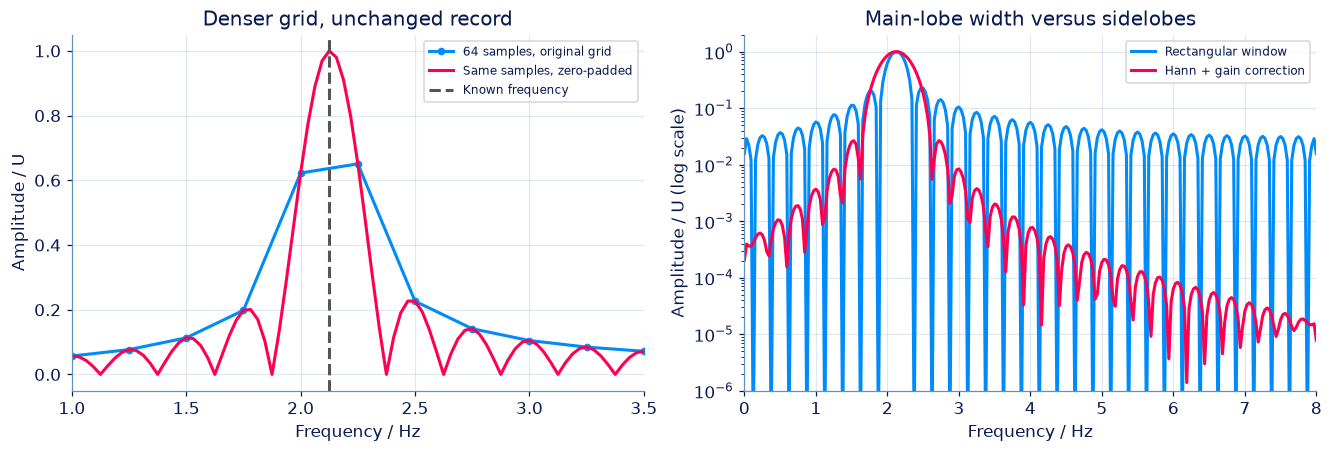

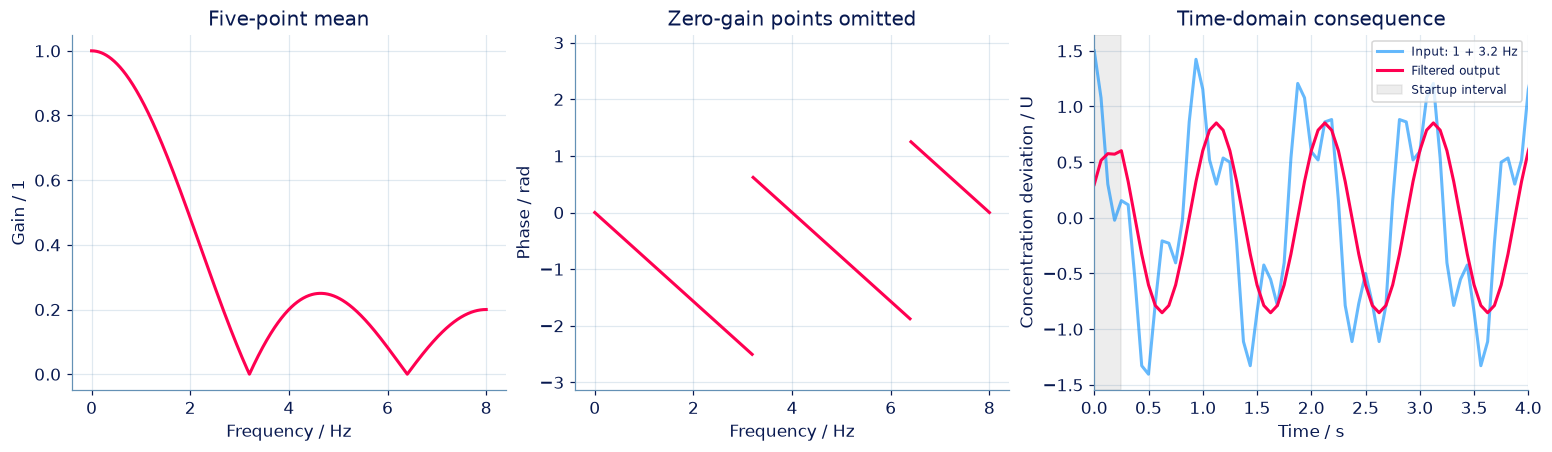

In [4]:
N=64;fs=16.;n=np.arange(N);f_true=2.125
x=np.cos(2*np.pi*f_true*n/fs)
fig,axes=plt.subplots(1,2,figsize=(12,4))
for padded,marker,label in [(N,'o','64 samples, original grid'),(8*N,None,'Same samples, zero-padded')]:
    f,a=record_spectrum(x,fs,np.ones(N),padded)
    axes[0].plot(f,a,marker=marker,ms=4,color=BLUE if padded==N else PINK,label=label)
axes[0].axvline(f_true,color=GRAY,ls='--',label='Known frequency')
axes[0].set(xlabel='Frequency / Hz',ylabel='Amplitude / U',xlim=(1,3.5),title='Denser grid, unchanged record')
for window,color,label in [(np.ones(N),BLUE,'Rectangular window'),(np.hanning(N),PINK,'Hann + gain correction')]:
    f,a=record_spectrum(x,fs,window,8*N)
    axes[1].semilogy(f,np.maximum(a,1e-7),color=color,label=label)
axes[1].set(xlabel='Frequency / Hz',ylabel='Amplitude / U (log scale)',xlim=(0,8),ylim=(1e-6,2),title='Main-lobe width versus sidelobes')
for ax in axes:ax.legend(fontsize=8)
plt.show()

kernel=np.ones(5)/5;frequencies=np.linspace(0,fs/2,801)
response=np.array(fir_response(kernel,frequencies,fs))
phase=np.angle(response);phase[np.abs(response)<1e-10]=np.nan
sample_index=np.arange(160);u=np.cos(2*np.pi*1*sample_index/fs)+.5*np.cos(2*np.pi*3.2*sample_index/fs)
y=np.convolve(u,kernel)[:len(u)]
fig,axes=plt.subplots(1,3,figsize=(14,4))
axes[0].plot(frequencies,np.abs(response),color=PINK)
axes[0].set(xlabel='Frequency / Hz',ylabel='Gain / 1',title='Five-point mean')
axes[1].plot(frequencies,phase,color=PINK)
axes[1].set(xlabel='Frequency / Hz',ylabel='Phase / rad',title='Zero-gain points omitted',ylim=(-np.pi,np.pi))
axes[2].plot(sample_index/fs,u,color=BLUE,alpha=.6,label='Input: 1 + 3.2 Hz')
axes[2].plot(sample_index/fs,y,color=PINK,label='Filtered output')
axes[2].axvspan(0,4/fs,color=GRAY,alpha=.1,label='Startup interval')
axes[2].set(xlabel='Time / s',ylabel='Concentration deviation / U',xlim=(0,4),title='Time-domain consequence');axes[2].legend(fontsize=8)
plt.show()

## 结果解释

补零曲线更密，却仍围绕同一个宽主瓣；Hann 窗的远旁瓣较低，主瓣则较宽。对数图从 $10^{-7}$ U 开始显示，原计算数组（array）保留全部数值。

五点核在 $f_s/5=3.2$ Hz 处增益为 0，理想稳态的这一成分被消去。1 Hz 成分保留下来，但振幅变小、相位推迟。启动的前四个输出缺少历史输入，与无限长正弦稳态公式不同。曲线说明的是给定滤波器的作用，不证明生理信号真的只包含两个节律。

### 独立核对

用几何和闭式检验复数求和；直接以满窗卷积核对幅度和相位；确认补零后每八个格点恢复原频率网格的相同值。

In [5]:
omega=2*np.pi*frequencies/fs
closed=np.ones_like(omega,dtype=complex)
closed[1:]=np.exp(-2j*omega[1:])*np.sin(5*omega[1:]/2)/(5*np.sin(omega[1:]/2))
np.testing.assert_allclose(response,closed,atol=2e-15)
np.testing.assert_allclose(fir_response(kernel,[0,3.2],fs),[1,0],atol=1e-14)
gain=fir_response(kernel,[1.,3.2],fs)
predicted=sum(amplitude*abs(g)*np.cos(2*np.pi*f*sample_index/fs+np.angle(g)) for amplitude,f,g in zip([1,.5],[1.,3.2],gain))
np.testing.assert_allclose(y[4:],predicted[4:],atol=8e-15)
f_small,a_small=record_spectrum(x,fs,np.ones(N),N)
f_large,a_large=record_spectrum(x,fs,np.ones(N),8*N)
np.testing.assert_allclose(f_large[::8],f_small)
np.testing.assert_allclose(a_large[::8],a_small,atol=1e-15)
print('复数响应、直流极限、消零频率、稳态卷积和补零网格检查通过。')

复数响应、直流极限、消零频率、稳态卷积和补零网格检查通过。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/06-02-卷积、频谱与频率响应/explore/)：改变采样或窗口条件，比较图形后返回本节推导。

## 练习与参考资料

习题由统一题库同步。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：不同频率通过滤波器后怎样变化

离散滤波核 h[m] 已给定。计算稳态复频率响应（frequency response）的模和相位（phase）；相位约定与频谱题一致。

**函数与代码模板**

```python
def solve(
    kernel: list[float],
    frequencies: list[float],
    sample_rate: float,
) -> tuple[list[float], list[float]]:
    # 按题目定义返回计算结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `kernel` | `list[float]` | 零延拓（zero extension）的因果FIR系数 h[0]…h[M−1]。 | 1 |
| `frequencies` | `list[float]` | 待检查的频率。 | Hz |
| `sample_rate` | `float` | 采样率（sampling rate）。 | Hz |

**返回值**

按以下顺序返回元组：(gains, phases)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `gains` | `list[float]` | abs(H)；不是平方功率增益（gain）。 | 1 |
| `phases` | `list[float]` | 主值相位；零增益时题定返回0。 | rad |

**计算规则**

H(f)=Σ_m kernel[m]*exp(−2πifm/sample_rate)。阈值1e−12*max(1,Σabs(kernel))以内的模与相位均返回0；其他相位 atan2(Im,Re)，距离−π≤1e−12映射为+π。

**约束与边界**

- 所有非缺测数值有限；不修改输入（input）列表。
- 1≤M≤20，系数绝对值≤10；0—40个频率，0≤f≤sample_rate/2；0.01≤sample_rate≤100。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| kernel | 零延拓（zero extension）的因果FIR系数 h[0]…h[M−1]。 | [0.5, 0.5] | 1 |
| frequencies | 待检查的频率。 | [0.0, 0.25, 0.5] | Hz |
| sample_rate | 采样率（sampling rate）。 | 1 | Hz |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
kernel = [0.5, 0.5]
frequencies = [0.0, 0.25, 0.5]
sample_rate = 1.0

result = solve(kernel, frequencies, sample_rate)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| gains | abs(H)；不是平方功率增益（gain）。 | [1.0, 0.7071067811865476, 0.0] | 1 |
| phases | 主值相位；零增益时题定返回0。 | [-0.0, -0.7853981633974483, 0.0] | rad |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([1.0, 0.7071067811865476, 0.0],
                   [-0.0, -0.7853981633974483, 0.0])
```

**样例解释**

两点均值核的增益约 [1,0.707107,0]，相位 [0,−π/4,0]。最后的相位0是零增益标记，不可解释为该频率无延迟（delay）。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：不同频率通过滤波器后怎样变化](http://127.0.0.1:8000/chapters/06-02-%E5%8D%B7%E7%A7%AF%E3%80%81%E9%A2%91%E8%B0%B1%E4%B8%8E%E9%A2%91%E7%8E%87%E5%93%8D%E5%BA%94/practice/?question=p06-fir-response)

### 第 2 题 · 多项选择题：频谱泄漏来自哪里

有限矩形记录内的余弦没有恰好包含整数周期。哪些正确？

- **A.** 窗函数（window function）可降低远处旁瓣，但会改变主瓣宽度和幅值标定。
- **B.** 泄漏与混叠（aliasing）是同一个概念。
- **C.** DFT周期延拓的边界通常不连续，会把能量分散到多个频点。
- **D.** 看到多个频点就能断定生理机制包含同样多振荡源。

[作答：频谱泄漏来自哪里](http://127.0.0.1:8000/chapters/06-02-%E5%8D%B7%E7%A7%AF%E3%80%81%E9%A2%91%E8%B0%B1%E4%B8%8E%E9%A2%91%E7%8E%87%E5%93%8D%E5%BA%94/practice/?question=p06-finite-leakage)

### 第 3 题 · 单项选择题：补零能增加什么

对已采到的N点记录补零到4N点，再计算DFT。哪项正确？

- **A.** 原样本的噪声方差（variance）自动降为1/4。
- **B.** 增加了独立观测（observation）长度。
- **C.** 频谱显示更密，但没有新增原始观察信息。
- **D.** 一定能分开任意接近的两种频率。

[作答：补零能增加什么](http://127.0.0.1:8000/chapters/06-02-%E5%8D%B7%E7%A7%AF%E3%80%81%E9%A2%91%E8%B0%B1%E4%B8%8E%E9%A2%91%E7%8E%87%E5%93%8D%E5%BA%94/practice/?question=p06-zero-padding)

### 第 4 题 · 多项选择题：均值滤波器的延迟在哪成立

固定W=5的因果均值核，采样率（sampling rate）1 Hz。哪些正确？

- **A.** 在第一非零通带内，相位（phase）斜率（slope）对应2 s延迟（delay）。
- **B.** 所有频率增益（gain）均为1。
- **C.** 零增益频点不能用相位计算有意义的延迟。
- **D.** 启动前按0延拓时，常数输入（input）最初几步可能被压低。

[作答：均值滤波器的延迟在哪成立](http://127.0.0.1:8000/chapters/06-02-%E5%8D%B7%E7%A7%AF%E3%80%81%E9%A2%91%E8%B0%B1%E4%B8%8E%E9%A2%91%E7%8E%87%E5%93%8D%E5%BA%94/practice/?question=p06-fir-delay-band)

### 第 5 题 · 单项选择题：给频谱乘窗后怎样报幅值

在同一记录上使用矩形窗（rectangular window）与Hann窗。哪项最可靠？

- **A.** 声明窗与归一化；整频点孤立正弦的幅值校正常用窗系数和，但离频点/多分量仍有偏差。
- **B.** 任何窗都能消除泄漏并保留无限分辨率。
- **C.** 窗函数（window function）可以恢复采样（sampling）前已丢失的高频。
- **D.** 直接比较未标定峰高，较低者意味着真实振幅（amplitude）下降。

[作答：给频谱乘窗后怎样报幅值](http://127.0.0.1:8000/chapters/06-02-%E5%8D%B7%E7%A7%AF%E3%80%81%E9%A2%91%E8%B0%B1%E4%B8%8E%E9%A2%91%E7%8E%87%E5%93%8D%E5%BA%94/practice/?question=p06-amplitude-calibration)

**进一步阅读**

[SciPy `freqz` 文档](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.freqz.html)：数字滤波器的复数频率响应定义；[NumPy FFT 文档](https://numpy.org/doc/stable/reference/routines.fft.html)：频率顺序与变换归一化。